In [1]:
from feature_extractor import get_features
from feature_extractor import split_sentences_max_words
import pandas as pd
import json
import os
from tqdm import tqdm
import json
from get_logprobs import LMLogProbs
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, f1_score, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import shuffle
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize
import re


ModuleNotFoundError: No module named 'numpy'

In [2]:
lm_models = {
    "gpt2": LMLogProbs("gpt2-medium"),
    #"pythia": LMLogProbs("EleutherAI/pythia-410m")
    #"neo": LMLogProbs("EleutherAI/gpt-neo-1.3B")
}

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:

pythia_chunks = []
gpt2_chunks = []

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)

#/home/udntn/AI/ai_detector/training_data/chunk_logprobs_gpt2-cheat-v6.jsonl
with open(output_dir + "chunk_logprobs_pythia_cheat-v6.jsonl") as f:
    for line in f:
        pythia_chunks.append(json.loads(line))
#/home/udntn/AI/ai_detector/training_data/chunk_logprobs_gpt2-cheat-v6.jsonl
with open(output_dir +"chunk_logprobs_gpt2-cheat-v6.jsonl") as f:
    for line in f:
        gpt2_chunks.append(json.loads(line))

print(len(gpt2_chunks))
print(len(pythia_chunks))


print(len(gpt2_chunks))
print(len(pythia_chunks))
gpt2_chunks = pd.DataFrame(gpt2_chunks)

pythia_chunks = pd.DataFrame(pythia_chunks)

# data cleansing
print(len(pythia_chunks))
pythia_chunks = pythia_chunks[pythia_chunks["text"].str.len() > 30]
print(len(pythia_chunks))
pythia_chunks = pythia_chunks.drop_duplicates(subset="text")
print(len(pythia_chunks))

pythia_chunks["len"] = pythia_chunks["text"].str.split().apply(len)

human = pythia_chunks[pythia_chunks.label == 0]
ai    = pythia_chunks[pythia_chunks.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

pythia_chunks = pythia_chunks[(pythia_chunks.len >= min_len) & (pythia_chunks.len <= max_len)]

pythia_chunks.label.value_counts()

print("final pythia count", len(pythia_chunks))


gpt2_chunks = pd.DataFrame(gpt2_chunks)

# data cleansing
print(len(gpt2_chunks))
gpt2_chunks = gpt2_chunks[gpt2_chunks["text"].str.len() > 30]
print(len(gpt2_chunks))
gpt2_chunks = gpt2_chunks.drop_duplicates(subset="text")
print(len(gpt2_chunks))

gpt2_chunks["len"] = gpt2_chunks["text"].str.split().apply(len)

human = gpt2_chunks[gpt2_chunks.label == 0]
ai    = gpt2_chunks[gpt2_chunks.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

gpt2_chunks = gpt2_chunks[(gpt2_chunks.len >= min_len) & (gpt2_chunks.len <= max_len)]

gpt2_chunks.label.value_counts()

print("final pythia count", len(gpt2_chunks))

114971
114971
114971
114971
114971
114971
114959
final pythia count 91454
114971
114971
114959
final pythia count 91454


In [4]:
import os
import json

#pythia_records = []
gpt2_records = []

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)


with open(output_dir +"sentence_logprobs_gpt2_raid-v3.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))


#broken essay count
with open(output_dir + "sentence_logprobs_gpt2_cheat_essayNum.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))

with open(output_dir + "sentence_logprobs_gpt2_ai-ga-dataset.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))

with open(output_dir + "sentence_logprobs_gpt2_aigtxt-dataset.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))

with open(output_dir + "sentence_logprobs_gpt2_AIvHuman.jsonl") as f:
    for line in f:
        gpt2_records.append(json.loads(line))


import os
import pandas as pd
import unicodedata
import regex as re

import pandas as pd

#pythia_records = pd.DataFrame(pythia_records)

# data cleansing
#print(len(pythia_records))
#pythia_records = pythia_records[pythia_records["text"].str.len() > 30]
#print(len(pythia_records))
#pythia_records = pythia_records.drop_duplicates(subset="text")
#print(len(pythia_records))
#
#pythia_records["len"] = pythia_records["text"].str.split().apply(len)
#
#human = pythia_records[pythia_records.label == 0]
#ai    = pythia_records[pythia_records.label == 1]
#
#min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
#max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))
#
#pythia_records = pythia_records[(pythia_records.len >= min_len) & (pythia_records.len <= max_len)]
#
#pythia_records.label.value_counts()
#
#print(len(pythia_records))
#
#
gpt2_records = pd.DataFrame(gpt2_records)

## data cleansing
print(len(gpt2_records))
gpt2_records = gpt2_records[gpt2_records["text"].str.len() > 30]
print(len(gpt2_records))
gpt2_records = gpt2_records.drop_duplicates(subset="text")
print(len(gpt2_records))

gpt2_records["len"] = gpt2_records["text"].str.split().apply(len)

human = gpt2_records[gpt2_records.label == 0]
ai    = gpt2_records[gpt2_records.label == 1]

min_len = max(human.len.quantile(0.05), ai.len.quantile(0.05))
max_len = min(human.len.quantile(0.95), ai.len.quantile(0.95))

gpt2_records = gpt2_records[(gpt2_records.len >= min_len) & (gpt2_records.len <= max_len)]

print(gpt2_records.label.value_counts())

print(len(gpt2_records))

#gpt2_records = shuffle(gpt2_records, random_state=42)#


def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"[\u0000-\u001F\u007F-\u009F]", "", s)      # control chars
    s = re.sub(r"[\u200B-\u200D\uFEFF]", "", s)            # zero-width
    s = re.sub(r"\s+", " ", s).strip()
    return s

def is_junk(s):
    if len(s) < 5:
        return True

    letters = len(re.findall(r"\p{L}", s))
    digits  = len(re.findall(r"\p{N}", s))
    spaces  = len(re.findall(r"\p{Zs}", s))
    total   = len(s)

    language_ratio = (letters + digits + spaces) / total

    if "�" in s:
        return True
    if language_ratio < 0.6:
        return True

    return False

# Apply cleaning
gpt2_records["text"] = gpt2_records["text"].apply(clean_text)

# Detect junk
gpt2_records["is_junk"] = gpt2_records["text"].apply(is_junk)
print("Junk rate:", gpt2_records["is_junk"].mean())

# Drop junk only
gpt2_records = gpt2_records[~gpt2_records["is_junk"]].reset_index(drop=True)
gpt2_records = gpt2_records.drop(columns=["is_junk"])

print("After cleaning:", len(gpt2_records))

count = 1
prev = gpt2_records.loc[0, "essayNum"]

Ai_count =0
human_count = 0

for i, row in enumerate(tqdm(gpt2_records.itertuples(index=False), total=len(gpt2_records))):
    if row.essayNum != prev:
        count += 1
        prev = row.essayNum

        if row.label == 0:
            human_count +=1
        else:
            Ai_count +=1
            
    gpt2_records.at[i, "essayNum"] = count



    
print(human_count)
print(Ai_count)



758065
738249
727418
label
0    362283
1    272358
Name: count, dtype: int64
634641
Junk rate: 9.454163850113686e-06
After cleaning: 634635


100%|██████████| 634635/634635 [00:07<00:00, 84569.11it/s]

45544
45450


In [27]:
import json
from tqdm import tqdm

output_dir = os.path.expanduser("~/AI/ai_detector/training_data/")
os.makedirs(output_dir, exist_ok=True)


gpt2_file = os.path.join(output_dir +"sentence_logprobs_pythia-cheat-v6.jsonl")
pythia_file = os.path.join(output_dir +"sentence_logprobs_gpt2-cheat-v6.jsonl")

out_gpt2 = os.path.join(output_dir, "sentence_logprobs_gpt2_aligned-cheat-v6.jsonl")
out_pythia = os.path.join(output_dir, "sentence_logprobs_pythia_aligned-cheat-v6.jsonl")

# --- load GPT2 ---
gpt2_map = {}
with open(gpt2_file, "r") as f:
    for line in tqdm(f, desc="Loading GPT2"):
        rec = json.loads(line)
        gpt2_map[rec["text"]] = rec

# --- load Pythia ---
pythia_map = {}
with open(pythia_file, "r") as f:
    for line in tqdm(f, desc="Loading Pythia"):
        rec = json.loads(line)
        pythia_map[rec["text"]] = rec

# --- intersection ---
common_sentences = list(set(gpt2_map.keys()) & set(pythia_map.keys()))
print("Common sentences:", len(common_sentences))

# --- write aligned files ---
with open(out_gpt2, "w") as f1, open(out_pythia, "w") as f2:
    for sent in tqdm(common_sentences, desc="Writing aligned"):
        f1.write(json.dumps(gpt2_map[sent]) + "\n")
        f2.write(json.dumps(pythia_map[sent]) + "\n")

print("✅ Done")
print("Wrote:")
print(out_gpt2)
print(out_pythia)

Loading GPT2: 206340it [00:03, 54454.44it/s]
Loading Pythia: 206342it [00:05, 34406.00it/s]


Common sentences: 206255


Writing aligned: 100%|██████████| 206255/206255 [00:12<00:00, 15932.42it/s]

✅ Done
Wrote:
/home/udntn/AI/ai_detector/training_data/sentence_logprobs_gpt2_aligned-cheat-v6.jsonl
/home/udntn/AI/ai_detector/training_data/sentence_logprobs_pythia_aligned-cheat-v6.jsonl


In [3]:
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, f1_score, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils import shuffle

In [ ]:

print("Computing features...")

x =[]
y = []


for pythia_rec, gpt2_rec in tqdm(
    zip(pythia_chunks.itertuples(index=False),
        gpt2_chunks.itertuples(index=False)),
    total=min(len(gpt2_chunks), len(gpt2_chunks))
):
    
    if gpt2_rec.text != pythia_rec.text:
        print("misaligned!")
        break
    
    gpt2_label = gpt2_rec.label
    results = get_features(pythia_rec, gpt2_rec)
    if results.all() == 0:
        continue

    x.append(results)
    y.append(gpt2_label)



x = np.vstack(x)
y = np.array(y)

x, y = shuffle(x, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (better for heavy tails)
# -----------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler_chunk_rf-v2.joblib")

# -----------------------------
# Random Forest (less overfit)
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

# -----------------------------
# Calibrate probabilities
# -----------------------------
cal = CalibratedClassifierCV(
    rf,
    method="isotonic",   # try "sigmoid" if isotonic overfits
    cv=5
)

cal.fit(X_train_scaled, y_train)

joblib.dump(cal, "chunk_rf_detector_calibrated-v2.joblib")

# -----------------------------
# Evaluation
# -----------------------------
y_pred = cal.predict(X_test_scaled)
y_proba = cal.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Threshold selection (NO leakage)
# -----------------------------
thresholds = np.linspace(0.05, 0.95, 181)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)
print("Best F1:", best_f1)

# Save threshold
with open("chunk_threshold.txt", "w") as f:
    f.write(str(best_t))

Computing features...


100%|██████████| 91454/91454 [00:54<00:00, 1690.83it/s]


Accuracy: 0.8869936034115139
ROC AUC: 0.9549999760871956
PR AUC: 0.9512698443360519

Classification Report:
              precision    recall  f1-score   support

       Human       0.90      0.88      0.89      9200
          AI       0.88      0.90      0.89      9091

    accuracy                           0.89     18291
   macro avg       0.89      0.89      0.89     18291
weighted avg       0.89      0.89      0.89     18291


Confusion Matrix:
[[8076 1124]
 [ 943 8148]]
Chosen threshold: 0.43499999999999994
Best F1: 0.8890432923570283


In [8]:
print("Computing features...")

x =[]
y = []

for gpt2_rec in tqdm(gpt2_records.itertuples(index=False), total=(len(gpt2_records))):

    gpt2_label = gpt2_rec.label
    
    results = get_features(gpt2_rec)
    if not results.any():
        continue

    
    x.append(results)
    y.append(gpt2_label)


Computing features...


100%|██████████| 634635/634635 [23:15<00:00, 454.65it/s]  


In [9]:
x = np.delete(x, [11, 12, 13, 14, 15, 19, 20, 21], axis=1)

In [10]:


x = np.vstack(x)
y = np.array(y)

x, y = shuffle(x, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Scaling (better for heavy tails)
# -----------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler_sentence_rf-all-data-with-read.joblib")

# -----------------------------
# Random Forest (less overfit)
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,      # instead of 600
    max_depth=15,         # instead of 20
    min_samples_leaf=10,  # instead of 5
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

# -----------------------------
# Calibrate probabilities
# -----------------------------
cal = CalibratedClassifierCV(
    rf,
    method="sigmoid",   # try "sigmoid" if isotonic overfits
    cv="prefit"
)

cal.fit(X_train_scaled, y_train)

joblib.dump(cal, "sentence_rf_detector_calibrated-all-data-with-read.joblib", compress=3)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = cal.predict(X_test_scaled)
y_proba = cal.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("PR AUC:", average_precision_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# -----------------------------
# Threshold selection (NO leakage)
# -----------------------------
thresholds = np.linspace(0.05, 0.95, 181)
best_t, best_f1 = 0.5, 0

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Chosen threshold:", best_t)
print("Best F1:", best_f1)

# Save threshold
with open("sentence_threshold.txt", "w") as f:
    f.write(str(best_t))


Accuracy: 0.7177511482978405
ROC AUC: 0.7890924091123812
PR AUC: 0.7361991592448274

Classification Report:
              precision    recall  f1-score   support

       Human       0.75      0.76      0.76     72456
          AI       0.68      0.66      0.67     54471

    accuracy                           0.72    126927
   macro avg       0.71      0.71      0.71    126927
weighted avg       0.72      0.72      0.72    126927


Confusion Matrix:
[[55344 17112]
 [18713 35758]]
Chosen threshold: 0.29
Best F1: 0.6948276265410679


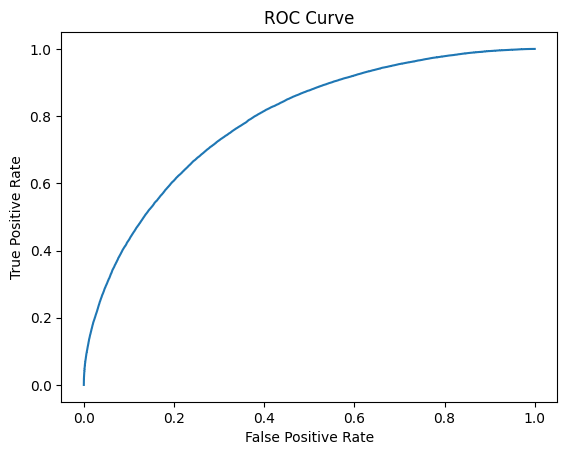

In [12]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

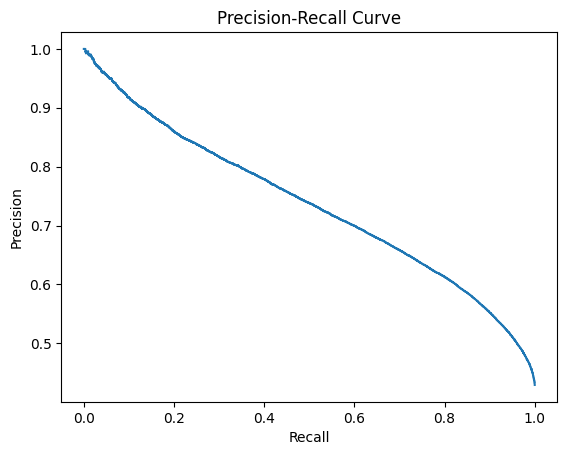

In [13]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

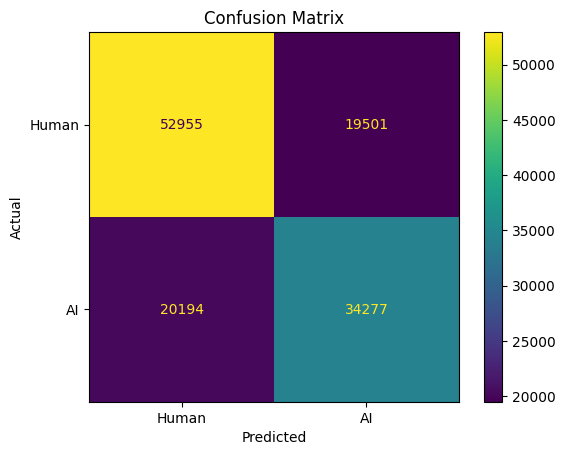

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(values_format="d")  # integer counts

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

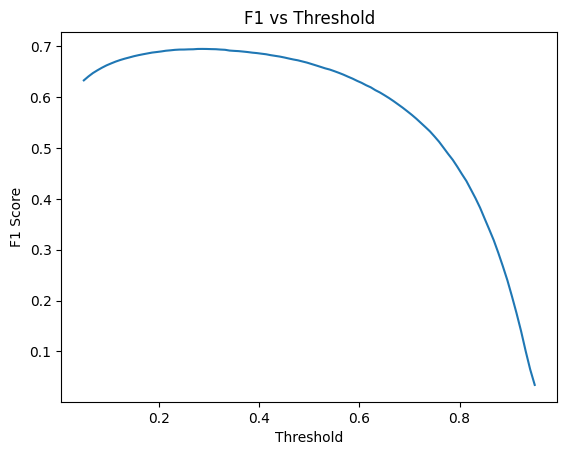

In [14]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.95, 100)
f1_scores = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.show()

Features: 20
Importances: 20
                 feature  importance
11      flesch_read_ease    0.100334
0                mean_lp    0.082069
14         mean_word_rep    0.081148
12  flesch_kincade_grade    0.078387
9               per10_lp    0.073899
2                 var_lp    0.067896
1                 std_lp    0.061907
6                 q25_lp    0.050759
13           gunning_fog    0.049918
5              median_lp    0.046133
19              word_var    0.045397
18              std_word    0.044001
8                 iqr_lp    0.039252
3                 min_lp    0.034714
10              per90_lp    0.034545
7                 q75_lp    0.033969
15          max_word_rep    0.026446
4                 max_lp    0.026415
16          max_word_len    0.018169
17          min_word_len    0.004641


/home/udntn/pytorch_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


                 feature  importance
11      flesch_read_ease    0.037439
14         mean_word_rep    0.033021
12  flesch_kincade_grade    0.022511
0                mean_lp    0.013504
10              per90_lp    0.005074
5              median_lp    0.004103
19              word_var    0.003879
18              std_word    0.003613
9               per10_lp    0.003131
13           gunning_fog    0.002342
7                 q75_lp    0.002121
15          max_word_rep    0.001793
2                 var_lp    0.001494
4                 max_lp    0.001401
1                 std_lp    0.001401
8                 iqr_lp    0.001278
6                 q25_lp    0.001180
16          max_word_len    0.000982
3                 min_lp    0.000693
17          min_word_len    0.000637


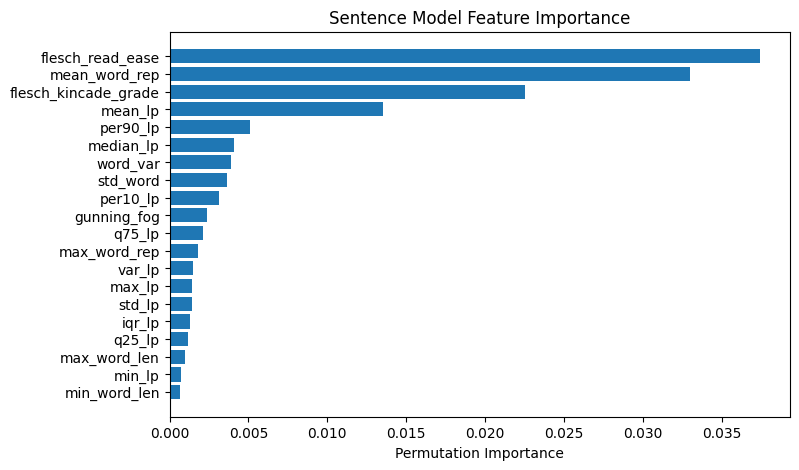

In [ ]:
import pandas as pd
import numpy as np

feature_names = [
    "mean_lp",
    "std_lp",
    "var_lp",
    "min_lp",
    "max_lp",
    "median_lp",
    "q25_lp",
    "q75_lp",
    "iqr_lp",
    "per10_lp",
    "per90_lp",
    #"skew_val",
    #"kurtosis_val",
    #"mean_ppl",
    #"entropy",
    #"cv_lp",
#
    "flesch_read_ease",
    "flesch_kincade_grade",
    "gunning_fog",
#
    #"loc_var_mean",
    #"loc_var_std",
    #"loc_var_max",
    #
    "mean_word_rep",
    "max_word_rep",
    "max_word_len",
    "min_word_len",
    "std_word",
    "word_var"
]



importances = rf.feature_importances_

print("Features:", len(feature_names))
print("Importances:", len(importances))

feat_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feat_df)

from sklearn.inspection import permutation_importance

result = permutation_importance(
    cal,                      # use calibrated model
    X_test_scaled,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": feature_names,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(perm_df)

import matplotlib.pyplot as plt

perm_df = perm_df.sort_values(by="importance")

plt.figure(figsize=(8, 5))
plt.barh(perm_df["feature"], perm_df["importance"])
plt.xlabel("Permutation Importance")
plt.title("Sentence Model Feature Importance")
plt.show()

In [5]:
BATCH_SIZE = 500  # batch sentences for prediction to save RAM
CACHE_DIR = "sentence_cache"
from tqdm import tqdm
import os

os.makedirs(CACHE_DIR, exist_ok=True)

# -----------------------------
# Load models
# -----------------------------
sentence_model = joblib.load("sentence_rf_detector_calibrated-all-data-with-read.joblib", mmap_mode="r")
sentence_scaler = joblib.load("scaler_sentence_rf-all-data-with-read.joblib")

/usr/lib/python3.12/contextlib.py:137: UserWarning: mmap_mode "r" is not compatible with compressed file sentence_rf_detector_calibrated-all-data-with-read.joblib. "r" flag will be ignored.
  return next(self.gen)


In [6]:
sentence_model = joblib.load("sentence_rf_detector_calibrated-cheat-raid.joblib", mmap_mode="r")
sentence_scaler = joblib.load("scaler_sentence_rf-cheat-raid.joblib")

In [7]:
meta_model = joblib.load("meta_classifier-v4.joblib", mmap_mode="r")
meta_scaler = joblib.load("scaler_meta-v4.joblib")

In [6]:
gpt2_essays  = {}
import numpy as np

essay_df = gpt2_records.groupby("essayNum").agg({
    "text": list,
    "mean": list,
    "label": "first",
    "std": list,
    "word_log_probs": list
}).reset_index()

essay_df = shuffle(essay_df)
print(len(essay_df))



90995


In [7]:
import numpy as np
from scipy.stats import entropy
# -----------------------------
# Utility functions
# -----------------------------
def predict_sentence_probs(texts, log_probs_list):
    """
    texts: list of sentences
    log_probs_list: list of word_log_probs (same length)
    """
    feats = []

    for sent, lp in zip(texts, log_probs_list):
        f = get_features(lp, sent)
        feats.append(f)

    X = np.vstack(feats)
    
    X = np.delete(X, [11, 12, 13, 14, 15, 19, 20, 21], axis=1)
    X_scaled = sentence_scaler.transform(X)
    probs = sentence_model.predict_proba(X_scaled)[:, 1]

    return probs

def get_chunk_features(sentence_probs, chunk_size=4):
    chunk_feats = []
    for i in range(0, len(sentence_probs), chunk_size):
        chunk = np.array(sentence_probs[i:i+chunk_size])
        chunk_feats.append([
            chunk.mean(),
            chunk.max(),
            chunk.min(),
            chunk.std(),
            np.percentile(chunk, 10),
            np.percentile(chunk, 90),
            np.median(chunk)
        ])
    return np.vstack(chunk_feats)


# -----------------------------
# Prepare meta features for one essay
# -----------------------------
def prepare_meta_features(texts, log_probs_list):
    # sentence-level probabilities
    sentence_probs = predict_sentence_probs(texts, log_probs_list)

    p = np.array(sentence_probs)

    if len(p) < 3:
        return np.zeros(14)

    # -----------------------------
    # 🔥 CORE DISTRIBUTION FEATURES
    # -----------------------------
    dist_feats = np.array([
        p.mean(),                         # overall confidence
        p.std(),                          # spread
        np.min(p),                        # weakest sentence
        np.percentile(p, 25),             # lower quartile
        np.percentile(p, 75),             # upper quartile
        entropy(p + 1e-8),                # randomness
    ])

    # -----------------------------
    # 🔥 LOW-PROBABILITY MASS (VERY IMPORTANT)
    # -----------------------------
    prop_feats = np.array([
        np.mean(p < 0.05),                # strongest signal
        np.mean(p < 0.1),
        np.mean(p < 0.2),
    ])

    # -----------------------------
    # 🔥 CHUNK EXTREMES (KEY)
    # -----------------------------
    chunk_feats = get_chunk_features(p)

    chunk_min = chunk_feats.min(axis=0)
    

    chunk_selected = np.concatenate([
        [chunk_min[2]],   # ✅ wrap
        [chunk_min[5]],   # ✅ wrap
    ])

    # -----------------------------
    # 🔥 POSITION SIGNAL
    # -----------------------------
    third = len(p) // 3
    if third > 0:
        pos_feats = np.array([
            p[:third].mean(),
            p[-third:].mean(),  # end_mean (important)
        ])
    else:
        pos_feats = np.zeros(2)

    #prop_grad= np.array([
    #    np.mean(np.diff(p)),
    #    np.std(np.diff(p)),
    #    np.max(np.abs(np.diff(p)))
    #])

    low_mask = (p < 0.1).astype(int)
    max_run = max_consecutive_ones(low_mask)/ len(p)

    # -----------------------------
    # FINAL VECTOR
    # -----------------------------
    meta_features = np.concatenate([
        dist_feats,
        prop_feats,
        chunk_selected,
        pos_feats,
        #prop_grad,
        [max_run]   # wrap scalar
    ])

    return meta_features.astype(np.float32)

def max_consecutive_ones(arr):
    max_run = 0
    current_run = 0

    for x in arr:
        if x == 1:
            current_run += 1
            if current_run > max_run:
                max_run = current_run
        else:
            current_run = 0

    return max_run

In [8]:


# -----------------------------
# Build meta dataset
# -----------------------------
def build_meta_dataset(df):
    X_meta = []
    y_meta = []
    for row in tqdm(df.itertuples(index=False), total=len(df)):
        
        meta_feat = prepare_meta_features(row.text, row.word_log_probs)
        X_meta.append(meta_feat)
        y_meta.append(row.label)

    return np.vstack(X_meta), np.array(y_meta)

# -----------------------------
# Load data
# ----------------------------- # columns: "text", "label"

# Split train/test
df_train, df_test = train_test_split(essay_df, test_size=0.2, stratify=essay_df['label'], random_state=42)

# Build meta features
print("Building train meta features...")
X_train_meta, y_train_meta = build_meta_dataset(df_train)

print("Building test meta features...")
X_test_meta, y_test_meta = build_meta_dataset(df_test)

# -----------------------------
# Scale meta features
# -----------------------------
scaler_meta = RobustScaler()
X_train_scaled = scaler_meta.fit_transform(X_train_meta)
X_test_scaled = scaler_meta.transform(X_test_meta)
joblib.dump(scaler_meta, "scaler_meta-all-data-v11.joblib")

# -----------------------------
# Train meta classifier
# -----------------------------
meta_clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
meta_clf.fit(X_train_scaled, y_train_meta)

from sklearn.calibration import CalibratedClassifierCV

calibrated_clf = CalibratedClassifierCV(
    meta_clf,
    method='isotonic',  # best for your dataset size
    cv=3
)

calibrated_clf.fit(X_train_scaled, y_train_meta)

joblib.dump(calibrated_clf, "meta_classifier-all-data-v11.joblib")

# -----------------------------
# Evaluate
# -----------------------------

y_proba = calibrated_clf.predict_proba(X_test_scaled)[:, 1]
y_pred = meta_clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_meta, y_pred))
print("F1 Score:", f1_score(y_test_meta, y_pred))
print("ROC AUC:", roc_auc_score(y_test_meta, y_proba))
print("PR AUC:", average_precision_score(y_test_meta, y_proba))
print("\nClassification Report:\n", classification_report(y_test_meta, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_meta, y_pred))

Building train meta features...


100%|██████████| 72796/72796 [1:14:03<00:00, 16.38it/s]


Building test meta features...


100%|██████████| 18199/18199 [18:35<00:00, 16.32it/s]


Accuracy: 0.8836199791197319
F1 Score: 0.884803654954857
ROC AUC: 0.9576662897379867
PR AUC: 0.9580906838713386

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      9109
           1       0.88      0.89      0.88      9090

    accuracy                           0.88     18199
   macro avg       0.88      0.88      0.88     18199
weighted avg       0.88      0.88      0.88     18199


Confusion Matrix:
 [[7947 1162]
 [ 956 8134]]


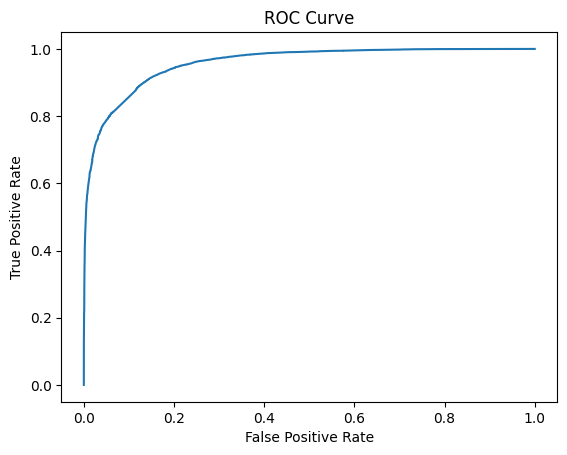

In [9]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test_meta, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

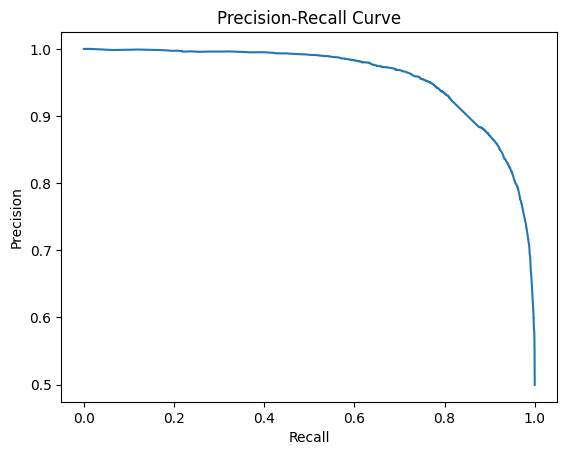

In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_meta, y_proba)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

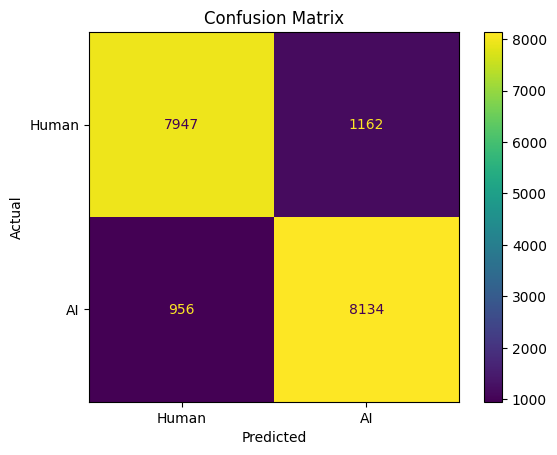

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_meta, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "AI"]
)

disp.plot(values_format="d")  # integer counts

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
import pandas as pd
import numpy as np

meta_feature_names = []

# ---- distribution (8) ----
meta_feature_names += [
    "p_mean", "p_std",
    "p_min", "p_q25", "p_q75",
    "p_entropy"
]
meta_feature_names += [
    "prop_gt_0.05", "prop_gt_0.1", "prop_lt_0.2"
]

# ---- chunk (5 base features × 3 aggregations = 15) ----
meta_feature_names += [
    #"chunk_med_mean",
    #"chunk_med_max",
    #"chunk_med_min",
    #"chunk_med_std",
    #"chunk_med_p10",
    #"chunk_med_p90",
    #"chunk_med_median",
    "chunk_min_min",
    "chunk_min_p10"
]


# ---- proportions (3) ----


# ---- position (3) ----
meta_feature_names += [
    "start_mean", 
    "end_mean"
]

#meta_feature_names += [
#    "prop_grad_mean", 
#     "prop_grad_std", "prop_grad_max"
#]
meta_feature_names += [
    "max_run"
]

# ---- structure (4) ----
# ---- essay (3) ----

# ✅ sanity check

print("Features:", len(meta_feature_names))
importances = meta_clf.feature_importances_
print("Importances:", len(importances))




Features: 14
Importances: 14



=== MODEL IMPORTANCE ===
          feature  importance
0          p_mean    0.216619
3           p_q25    0.134554
8     prop_lt_0.2    0.129052
7     prop_gt_0.1    0.110529
4           p_q75    0.085414
13        max_run    0.080285
9   chunk_min_min    0.058497
2           p_min    0.051143
12       end_mean    0.049493
10  chunk_min_p10    0.035315
6    prop_gt_0.05    0.014291
11     start_mean    0.012870
5       p_entropy    0.011572
1           p_std    0.010366

=== PERMUTATION IMPORTANCE ===
          feature  importance
0          p_mean    0.020551
12       end_mean    0.004330
3           p_q25    0.003736
8     prop_lt_0.2    0.003638
11     start_mean    0.003341
13        max_run    0.002978
7     prop_gt_0.1    0.002912
5       p_entropy    0.002583
4           p_q75    0.001352
9   chunk_min_min    0.000879
2           p_min    0.000868
10  chunk_min_p10    0.000747
1           p_std    0.000582
6    prop_gt_0.05    0.000220


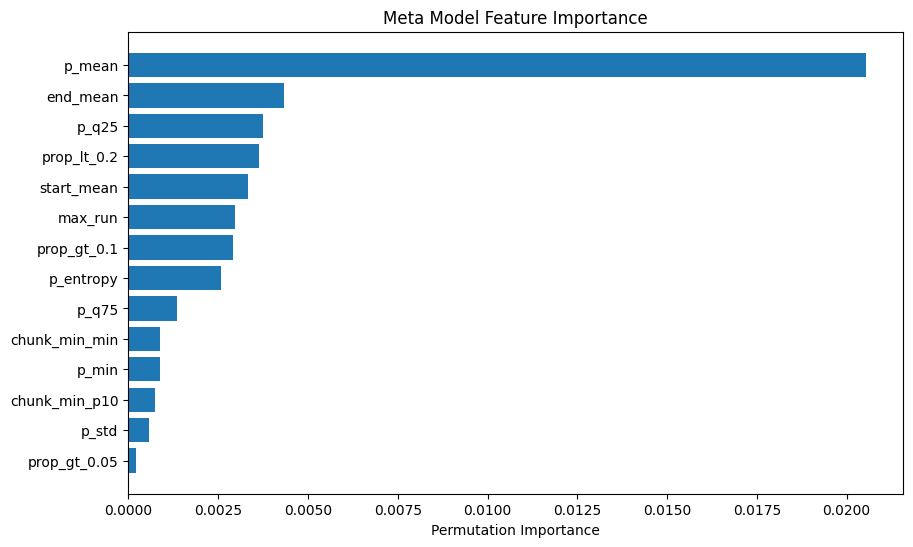

In [13]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

def analyze_meta_features(model, X_test, y_test, feature_names):
    # -----------------------------
    # 1. Built-in importance (RF only)
    # -----------------------------
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values(by="importance", ascending=False)

        print("\n=== MODEL IMPORTANCE ===")
        print(df)

    # -----------------------------
    # 2. Permutation importance (REAL)
    # -----------------------------
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=5,
        random_state=42,
        n_jobs=-1
    )

    perm_df = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values(by="importance", ascending=False)

    print("\n=== PERMUTATION IMPORTANCE ===")
    print(perm_df)

    # -----------------------------
    # 3. Plot
    # -----------------------------
    perm_df_sorted = perm_df.sort_values(by="importance")

    plt.figure(figsize=(10, 6))
    plt.barh(perm_df_sorted["feature"], perm_df_sorted["importance"])
    plt.title("Meta Model Feature Importance")
    plt.xlabel("Permutation Importance")
    plt.show()

    return perm_df

perm_df = analyze_meta_features(
    meta_clf,         # or calibrated model
    X_test_scaled,
    y_test_meta,
    meta_feature_names
)

In [ ]:
scaler_meta = RobustScaler()
X_train_scaled = scaler_meta.fit_transform(X_train_meta)
X_test_scaled = scaler_meta.transform(X_test_meta)
joblib.dump(scaler_meta, "scaler_meta-all-data-lf.joblib")

# -----------------------------
# Train meta classifier
# -----------------------------
meta_clf = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    solver="lbfgs",
    n_jobs=-1
)

meta_clf.fit(X_train_scaled, y_train_meta)

cal = CalibratedClassifierCV(
    meta_clf,
    method="sigmoid",   # try "sigmoid" if isotonic overfits
    cv="prefit"
)

cal.fit(X_train_scaled, y_train_meta)
joblib.dump(cal, "meta_classifier-all-data-lf.joblib", compress=3)

# -----------------------------
# Evaluate
# -----------------------------
y_pred = cal.predict(X_test_scaled)
y_proba = cal.predict_proba(X_test_scaled)[:, 1]

y_proba = cal.predict_proba(X_test_scaled)[:, 1]

threshold = 0.6   # try 0.6–0.8
y_pred = (y_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test_meta, y_pred))
print("F1 Score:", f1_score(y_test_meta, y_pred))
print("ROC AUC:", roc_auc_score(y_test_meta, y_proba))
print("PR AUC:", average_precision_score(y_test_meta, y_proba))
print("\nClassification Report:\n", classification_report(y_test_meta, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_meta, y_pred))

NameError: name 'LogisticRegression' is not defined

In [8]:
import pandas as pd
import torch
import json
from tqdm import tqdm
from itertools import chain
import os

BATCH_SIZE = 16       # Number of sentences per batch
MAX_TOKENS = 1024     # Max tokens per sentence
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
window = 4

for model_name, lm in lm_models.items():
    if lm.tokenizer.pad_token is None:
        lm.tokenizer.pad_token = lm.tokenizer.eos_token
    lm.model.to(DEVICE)
    lm.model.eval()
    lm.model.half()

def get_batch_token_logprobs_and_tokens(lm, texts, max_length=MAX_TOKENS):
    enc = lm.tokenizer(
        texts,
        return_tensors="pt",
        padding="max_length",
        truncation=True,
        max_length=max_length
    ).to(DEVICE)

    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            out = lm.model(input_ids=input_ids, attention_mask=attention_mask)
            log_probs = torch.nn.functional.log_softmax(out.logits, dim=-1)
    
            token_logps = log_probs.gather(
                2, input_ids[:, 1:].unsqueeze(-1)
            ).squeeze(-1)

    lengths = attention_mask.sum(dim=1) - 1

    results = []
    for i in range(len(texts)):
        L = lengths[i].item()
        toks = lm.tokenizer.convert_ids_to_tokens(input_ids[i, 1:L+1])
        lps = token_logps[i, :L].cpu().numpy()
        results.append((toks, lps))

    return results

In [ ]:
def sentence_probs(text):
    sentences = split_sentences_max_words(text)

    results = []

    for s in sentences:

        tokens_gpt2, log_probs_gpt2 = get_batch_token_logprobs_and_tokens(lm_models["gpt2"], [s])[0]
        #tokens_pythia, log_probs_pythia = get_batch_token_logprobs_and_tokens(lm_models["pythia"], [s])[0]
        results.append({
            "sentence": s,
            "log_prob": log_probs_gpt2
        })

    return results

def chunk_probs(text):
    sentences = split_sentences_max_words(text)

    if len(sentences) <= window:
        chunks = [" ".join(sentences)]
    else:
        chunks = []
        for j in range(0, len(sentences) - window + 1, 1):
            chunks.append(" ".join(sentences[j:j+window]))

    results = []

    for c in chunks:
            
        tokens_gpt2, log_probs_gpt2 = get_batch_token_logprobs_and_tokens(lm_models["gpt2"], [c])[0]
        #tokens_pythia, log_probs_pythia = get_batch_token_logprobs_and_tokens(lm_models["pythia"], [c])[0]  

        feats = get_features(log_probs_gpt2, c)
    
        if feats is None:
            continue

        
        feats = feats.reshape(1, -1)   # 🔑 REQUIRED

        #Xc = scaler_chunk.transform(feats)
        #prob = chunk_model.predict_proba(Xc)[0, 1]
#
        #print("Chunk feats:", combined)
        #print("Any NaN:", np.isnan(combined).any())
        #print("Std:", np.std(combined))

        results.append({
            "chunk": c,
            "prob": float(prob),
            "length": len(c.split())
        })

    return results

def predict_essay(text):
    sent_results = sentence_probs(text)


    meta_features = prepare_meta_features(sent_results)
    #chunk_results = chunk_probs(text)

    return {
        "sentences": sent_results,
        #"chunks": chunk_results
    }

In [ ]:
def check_logprobs(s):
    tokens_gpt2, log_probs_gpt2 = get_batch_token_logprobs_and_tokens(lm_models["gpt2"], [s])[0]
   # tokens_pythia, log_probs_pythia = get_batch_token_logprobs_and_tokens(lm_models["pythia"], [s])[0]
    print(log_probs_gpt2)
    print(log_probs_pythia)


check_logprobs("However, the PF algorithm needs a large number of samples to approximate the posterior probability density of the system, which makes the algorithm complex.")
    

  


/tmp/ipykernel_110235/594855155.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[-8.46512243e-03 -1.95442748e+00 -1.15205965e+01 -1.60787296e+01
 -5.56543732e+00 -2.43787551e+00 -4.82036304e+00 -1.46667182e+00
 -3.75233702e-02 -4.62603426e+00 -1.14488137e+00 -6.77179909e+00
 -7.85326600e-01 -7.26093864e+00 -1.78790784e+00 -3.38204670e+00
 -4.25951052e+00 -8.82406890e-01 -5.01891041e+00 -1.88317823e+00
 -1.47932827e+00 -4.39558125e+00 -1.83421397e+00 -3.16862345e+00
 -5.46151400e+00 -7.74179578e-01]
[ -0.09839956  -1.8068287  -11.099407    -5.9545894   -5.5567713
  -2.0617735   -2.9781737   -1.025465    -0.01818122  -3.0590425
  -1.0957692   -4.4828086   -0.38292873  -3.6401026   -2.474638
  -2.3415189   -1.8149593   -0.70917565  -6.439562    -2.6537628
  -1.188398    -2.6252646   -0.7972478   -2.0810483   -4.172726
  -1.2239382 ]


In [16]:


# -----------------------------
# Load models and scalers
# -----------------------------


# -----------------------------
# Parameters
# -----------------------------
SENT_THRESHOLD = 0.39
CHUNK_THRESHOLD = 0.43

W_SENT = 0.4   # weight for sentence model
W_CHUNK = 0.6  # weight for chunk model

# -----------------------------
# Essay-level prediction
# -----------------------------

# -----------------------------
# Example usage
# -----------------------------
while True:
    text = input("\nPaste an essay (or 'quit'): ")
    if text.strip().lower() == "quit":
        break

    result = predict_essay(text)  

    print("\n--- Sentence probabilities ---")
    for r in result["sentences"]:
        print(f"{r['prob']:.3f} | {r['sentence']}")

    #print("\n--- Chunk probabilities ---")
    #for r in result["chunks"]:
    #    print(f"{r['prob']:.3f} | {r['chunk']}")
    essay_prob = np.std([r['prob'] for r in result['sentences']],
        weights=[r['length'] for r in result['sentences']]
    )
    print(f"Essay-level AI probability: {essay_prob:.3f}")
    #essay_prob = np.average(sent_probs, weights=[r['length'] for r in result['sentences']])
    #print(f"Essay-level AI probability: {sent_probs :.3f}")

    
    #print("Combined prob:", result["combined_prob"])
    #print("Prediction:", result["prediction"])


/tmp/ipykernel_171896/594855155.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_171896/594855155.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_171896/594855155.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_171896/594855155.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_171896/594855155.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_17189


--- Sentence probabilities ---
0.258 | This study investigated the use of and satisfaction with RamaCovid, a mobile health (mHealth) education system that provides Thai people with information about COVID-19 and self-risk assessment.
0.193 | The system includes a chatbot system (available 24/7), live chat with health professionals (available 4 hours per day in the evening), vaccine information, self-care after vaccination, frequently asked questions, self-risk assessment, hospital finding, and contact number finding.
0.678 | 400 participants were recruited via RamaCovid, and a 5-point Likert scale questionnaire was used to collect data about their experiences and satisfaction with the system.
0.886 | Descriptive statistics and the Mann-Whitney U test were used to analyze the data.
0.503 | Results showed that participants reported high use of and satisfaction with RamaCovid.
0.874 | They used the information to take care of themselves and their family, and they were satisfied because t

TypeError: std() got an unexpected keyword argument 'weights'

In [1]:
from raid import run_detection, run_evaluation
from raid.utils import load_data

# Define your detector function
#def my_detector(texts: list[str]) -> list[float]:
#    pass
#
## Download & Load the RAID dataset
#train_df = load_data(split="train")
#
## Run your detector on the dataset
#predictions = run_detection(my_detector, train_df)
#
## Evaluate your detector predictions
#evaluation_result = run_evaluation(predictions, train_df)